## **Problem Statement: Airbnb Hotel Booking Analysis.**

The hospitality industry has undergone a significant transformation with the rise of online platforms facilitating short-term lodging and tourism.
Leading this revolution is Airbnb, Inc., a pioneering American company that has reshaped travel accommodation through its innovative online marketplace. Established in 2008 in San Francisco, California, Airbnb provides a diverse range of lodging options, offering guests a unique and personalized experience. Unlike traditional hospitality providers, Airbnb operates on a commission-based model, facilitating transactions between hosts and guests without owning the properties listed on its platform.

This research analysis delves into the New York City Airbnb dataset to extract meaningful insights. Through rigorous data cleaning, exploratory analysis, and visualization techniques, the study aims to illuminate the dynamics of the city's lodging market. By discerning factors influencing listing availability, pricing strategies, and overall customer satisfaction, the research contributes to a deeper understanding of Airbnb's operations in one of the world's most dynamic urban environments. These insights hold significance for stakeholders and enthusiasts seeking to navigate the evolving landscape of short-term accommodation.

**QUESTIONS**

This project is aimed to uncover some insights from the Airbnb Open Data. The following questions would be answered from the data.

1. What are the different property types in the Dataset?
2. Which neighborhood group has the highest number of listings?
3. Which neighborhoods group have the highest average prices for Airbnb listings?
4. Is there a relationship between the construction year of property and price?
5. Who are the top 10 hosts by calculated host listing count?
6. Are hosts with verified identities more likely to receive positive reviews?
7. Is there a correlation between the price of a listing and its service fee?
8. What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?
9. Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
#Read the Airbnb Data
df = pd.read_csv('/content/1730285881-Airbnb_Open_Data.csv', low_memory=False)

**ACCESS THE DATA**

In [ ]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7855 entries, 0 to 7854
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7855 non-null   int64  
 1   NAME                            7792 non-null   object 
 2   host id                         7855 non-null   int64  
 3   host_identity_verified          7782 non-null   object 
 4   host name                       7832 non-null   object 
 5   neighbourhood group             7828 non-null   object 
 6   neighbourhood                   7839 non-null   object 
 7   lat                             7847 non-null   float64
 8   long                            7847 non-null   float64
 9   country                         7805 non-null   object 
 10  country code                    7776 non-null   object 
 11  instant_bookable                7776 non-null   object 
 12  cancellation_policy             78

In [ ]:
df.duplicated().value_counts()

,count
False,7855


In [ ]:
#Neighbourhood group was 'brookln' instead of 'Brooklyn'
df[df['neighbourhood group'] == 'brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,6/24/2019,1.34,4.0,3.0,47.0,NaN,NaN


**Problems Identified within the Data**

• 541 duplicated Records where found in the Data.

• Insufficient information were recorded for the house_rules and Licence columns.

• Dollar signs and commas recorded along with the values for price and service fee.

• The currency for price and service fee were not added to the column's titles.

• Missing values in some records

• Columns like the price, service fee, id, host id, last review, Construction year are assigned wrong datatypes.

• In the neighbourhood group column the spelling of 'Brooklyn' was misspelt in some records.

• Some outliers were identified in the availability 365 column.

**CLEAN THE DATA**

**Steps to be Taken for Data Cleaning**

• Drop duplicated records.

• Drop house_rules and license columns with insufficient data.

• Remove all dollar signs in the price and service fee columns.

• Remove all commas from the price and service fee columns.

• Rename the price and service fee columns to include a dollar signs.

• Drop all records with missing values.

• Change all mismatched data types to the appropriate once.

• Correct the Spelling of 'brookin' to 'Brooklyn'.

• Get rid of outliers in the 'availability 365' column data.


In [ ]:
#Drop duplicate records
df.drop_duplicates(inplace=True)

# Rename the price and service fee columns to include a dollar signs.
df.rename(columns={'price': 'price_$', 'service fee': 'service_fee_$'}, inplace=True)

#Remove all dollar signs and commas in the price and service fee columns
df['price_$'] = df['price_$'].astype(str).str.replace(r'[$,]', '', regex= True)
df['service_fee_$'] = df['service_fee_$'].astype(str).str.replace(r'[$,]', '', regex= True)

#Change all mismatched data types to the appropriate once.
df[ 'price_$'] = pd.to_numeric(df[ 'price_$'], errors='coerce')
df[ 'service_fee_$'] = pd.to_numeric(df['service_fee_$'], errors='coerce')
df[ 'id'] = df['id'].astype(str)
df[ 'host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Drop rows with NaN in 'Construction year' before converting to int
df.dropna(subset=['Construction year'], inplace=True)
df[ 'Construction year'] = df[ 'Construction year'].astype(int)

#Correct the spelling of 'brookln' to 'Brooklyn'
df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

In [ ]:
df.duplicated().value_counts()

,count
False,7712


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7712 entries, 0 to 7854
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              7712 non-null   object        
 1   NAME                            7657 non-null   object        
 2   host id                         7712 non-null   object        
 3   host_identity_verified          7656 non-null   object        
 4   host name                       7694 non-null   object        
 5   neighbourhood group             7690 non-null   object        
 6   neighbourhood                   7696 non-null   object        
 7   lat                             7705 non-null   float64       
 8   long                            7705 non-null   float64       
 9   country                         7671 non-null   object        
 10  country code                    7642 non-null   object        
 11  instant_b

**EDA**

In [ ]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,license
count,7705.000000,7705.000000,7712.000000,7683.000000,7681.000000,7627.000000,7702.000000,6798,6807.000000,7621.000000,7692.000000,7583.000000,0.0
mean,40.729182,-73.959338,2012.420773,619.497202,123.749902,9.633014,49.352116,2018-05-11 03:10:51.368049664,0.897716,3.014696,2.668487,207.656073,NaN
min,40.508680,-74.239860,2003.000000,50.000000,10.000000,-12.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000,NaN
25%,40.688640,-73.983830,2007.000000,323.000000,65.000000,2.000000,3.000000,2017-06-11 00:00:00,0.130000,2.000000,1.000000,97.000000,NaN
50%,40.723100,-73.958990,2012.000000,619.000000,124.000000,3.000000,18.000000,2019-04-04 00:00:00,0.410000,3.000000,1.000000,210.000000,NaN
75%,40.763870,-73.943430,2017.000000,914.000000,183.000000,5.000000,65.000000,2019-06-19 00:00:00,1.250000,4.000000,2.000000,317.000000,NaN
max,40.908040,-73.729010,2022.000000,1200.000000,240.000000,3455.000000,607.000000,2058-06-16 00:00:00,13.450000,5.000000,96.000000,426.000000,NaN
std,0.051946,0.036032,5.783560,336.518738,67.229338,51.132349,71.258874,NaN,1.138870,1.419694,6.963813,126.305450,NaN


**What are the different property types in the Dataset?**

In [ ]:
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,4568
Private room,3036
Shared room,108


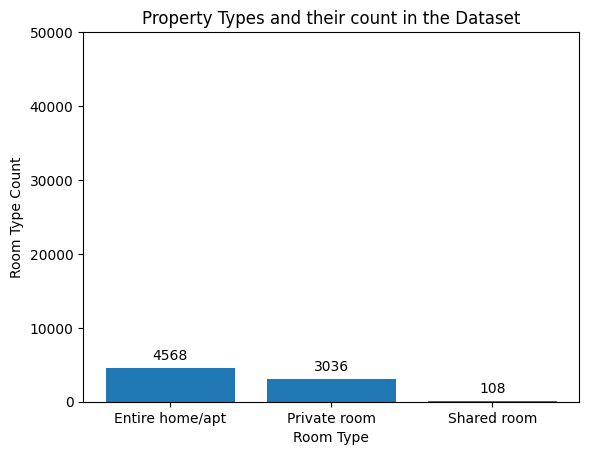

In [ ]:
#Room type count plotted on a barchart
room_type_bar = plt.bar(property_types.index, property_types.loc[:, "count"] );
plt.bar_label(room_type_bar, labels = property_types. loc[:, "count"], padding = 4 );
plt.ylim([0,50000]);
plt.xlabel ('Room Type');
plt.ylabel ('Room Type Count');
plt.title('Property Types and their count in the Dataset');

**Which neighborhood group has the highest number of listings?**

In [ ]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Manhattan,3541
Brooklyn,3433
Queens,569
Bronx,102
Staten Island,44
manhatan,1


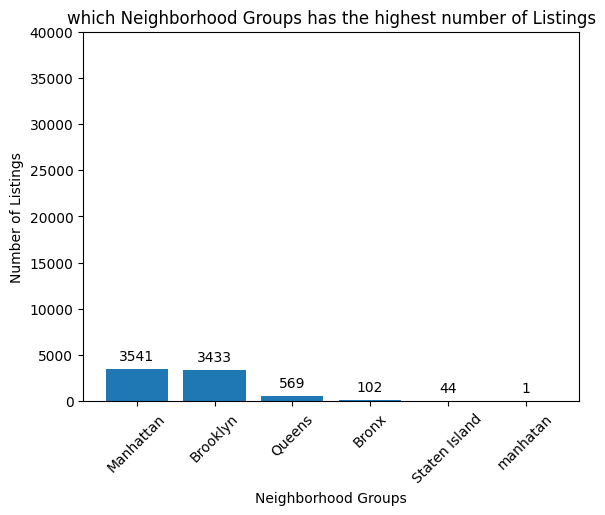

In [ ]:
#which neighborhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:,"count" ]);
plt.bar_label(hood_group_bar, labels = hood_group.loc[:,"count"], padding = 4 );
plt.ylim([0,40000]);
plt.xlabel ('Neighborhood Groups'); plt.ylabel('Number of Listings');
plt.xticks(rotation = 45);
plt.title('which Neighborhood Groups has the highest number of Listings');

**Which neighborhoods group have the highest average prices for Airbnb listings?**

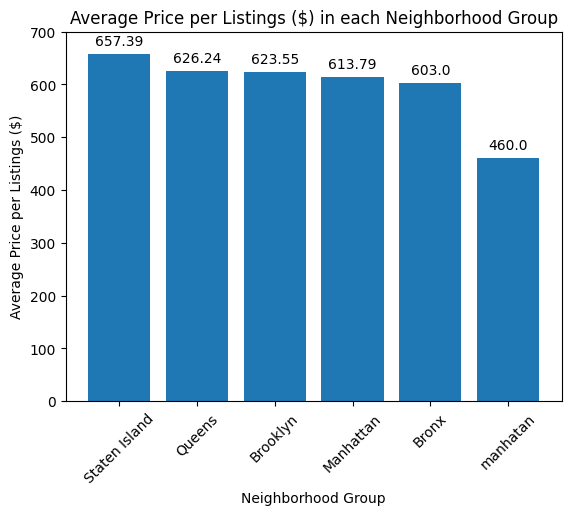

In [ ]:
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending = False).to_frame()
avg_price_bar = plt.bar(avg_price.index, avg_price. loc[:, 'price_$']);
plt.bar_label(avg_price_bar, labels = round(avg_price.loc[:,"price_$"], 2), label_type = "edge"
, padding = 4 );
plt.ylim([0,700]);
plt.xlabel ('Neighborhood Group');
plt.ylabel('Average Price per Listings ($)');
plt.xticks(rotation = 45);
plt. title('Average Price per Listings ($) in each Neighborhood Group');

**Is there a relationship between the construction year of property and price?**

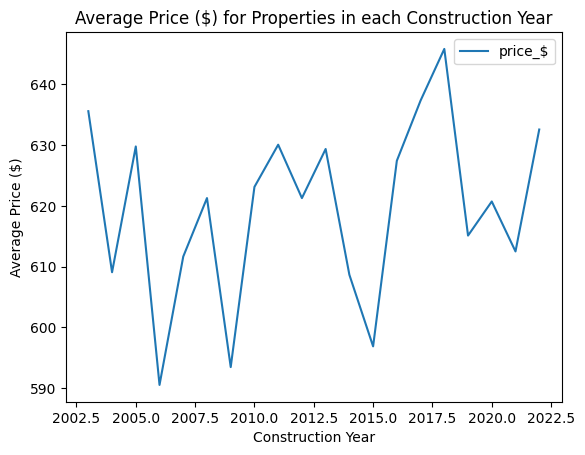

In [ ]:
df.groupby(df[ 'Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.title('Average Price ($) for Properties in each Construction Year');

**Who are the top 10 hosts by calculated host listing count?**

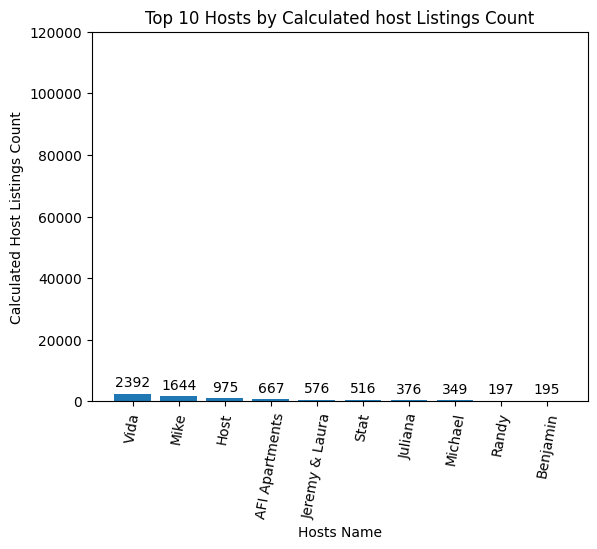

In [ ]:
hosts = df.groupby( 'host name') ['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:,'calculated host listings count' ]);
plt.bar_label(hosts_bar, label = hosts. loc[:,
'calculated host listings count'], label_type = 'edge', padding = 3);
plt.xlabel("Hosts Name" );
plt.ylabel ("Calculated Host Listings Count");
plt.xticks(rotation = 80);
plt.ylim([0, 120000]);
plt.title('Top 10 Hosts by Calculated host Listings Count');

The bar chart above illustrates the top 10 hosts based on the calculated listing count, with Sonder (NYC) notably leading with 111,921 listings.
Subsequently, the other hosts follow in descending order.

• Karen at second postion with 42410 hosts

• Jeniffer at third position with 31447 hosts

• Blueground at fourth position with 21168 hosts

• Kaz at fifth position with 17552 hosts

• Corporate Housing at sixth position with 14833 hosts

• Soya at seventh positon with 10260 hosts

• Stay with vibe at eight position with 10260 hosts

• Kara at ninth position with 10092 hosts

• and finally Jeremy and Laura at tenth position 10080 hosts

Are hosts with verified identities more likely to receive positive reviews?

In [ ]:
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
unconfirmed,3.019012
verified,3.007126


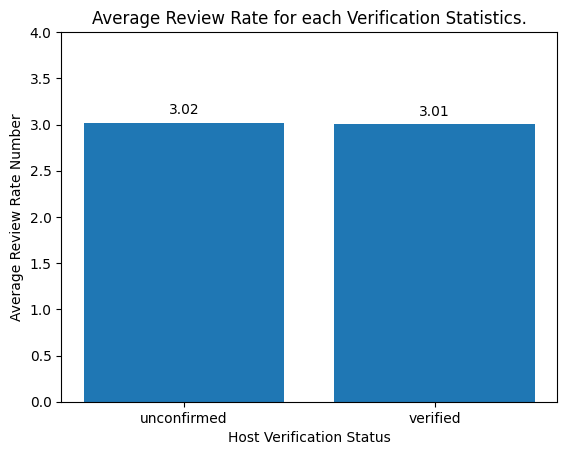

In [ ]:
review_bar = plt.bar(review.index, review.loc[:, "review rate number"]);
plt.bar_label(review_bar, labels = round(review.loc[:,"review rate number"], 2), padding = 4 );
plt.ylim([0,4]);
plt.xlabel ('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate for each Verification Statistics.');

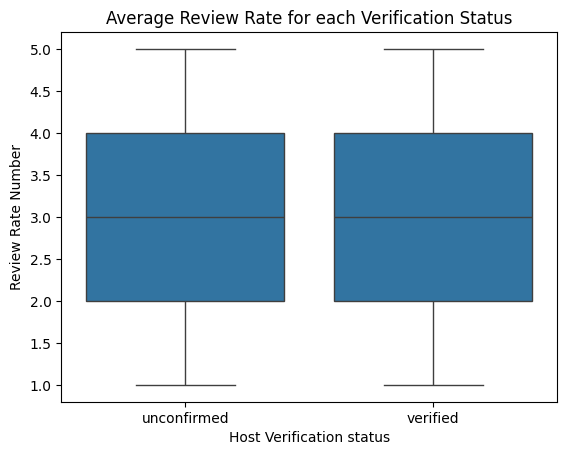

In [ ]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = "host_identity_verified", y = "review rate number", color = base_color);
plt.xlabel('Host Verification status');
plt.ylabel ('Review Rate Number');
plt.title('Average Review Rate for each Verification Status');

**Is there a correlation between the price of a listing and its service fee?**

In [ ]:
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999912893117551)

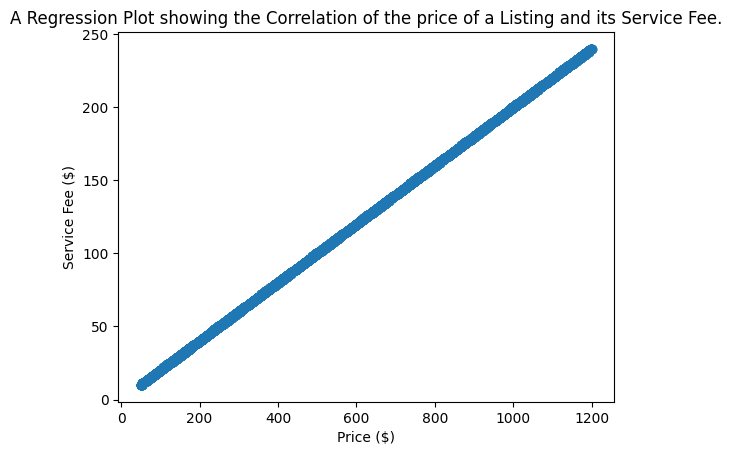

In [ ]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel('Price ($)');
plt.ylabel('Service Fee ($)');
plt.title('A Regression Plot showing the Correlation of the price of a Listing and its Service Fee.');

What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?

In [ ]:
ARRN = df.groupby(['neighbourhood group' ,"room type"])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            2.966667
                    Private room               2.898551
                    Shared room                1.333333
Brooklyn            Entire home/apt            2.970844
                    Private room               3.086525
                    Shared room                2.851852
Manhattan           Entire home/apt            3.018486
                    Private room               3.014605
                    Shared room                2.918033
Queens              Entire home/apt            2.915254
                    Private room               3.053797
                    Shared room                3.250000
Staten Island       Entire home/apt            3.227273
                    Private room               2.789474
manhatan            Private room               3.000000

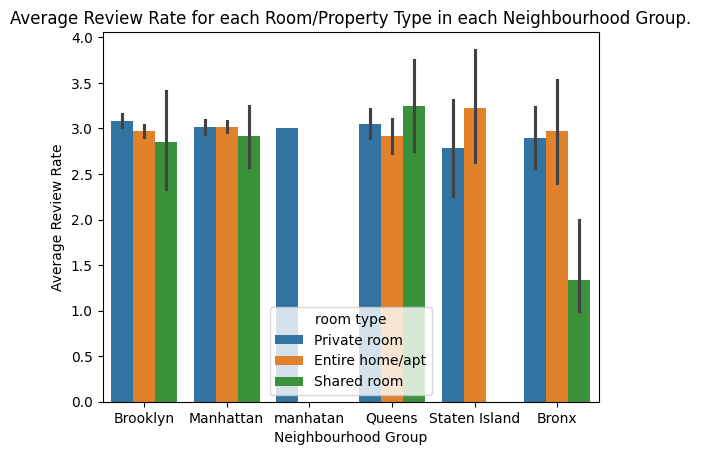

In [ ]:
plt.Figure(figsize = [12,10]);
sns.barplot(data = df , x = 'neighbourhood group', y = 'review rate number', hue = 'room type');
plt.xlabel ('Neighbourhood Group');
plt.ylabel ('Average Review Rate');
plt.title('Average Review Rate for each Room/Property Type in each Neighbourhood Group.');

**Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?**

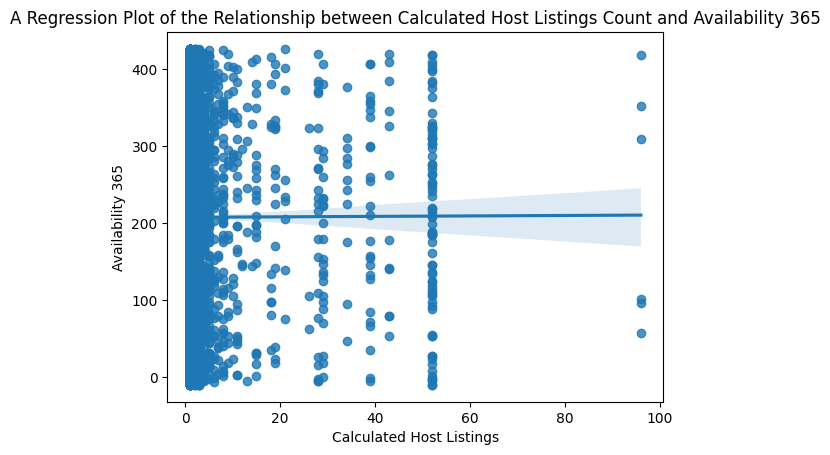

In [ ]:
sns.regplot(df, x = 'calculated host listings count', y = 'availability 365');
plt.xlabel ('Calculated Host Listings');
plt.ylabel('Availability 365');
plt.title('A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365');

In [ ]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.001646411992382001)